<a href="https://colab.research.google.com/github/Lekanggy/MLrepo/blob/main/RNN(Word2Vec.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Load Data

In [5]:
file = open('project1.txt', 'r')
royal_data = file.readlines()

print(royal_data)

['The future king is the prince\n', 'Daughter is the princess\n', 'Son is the prince\n', 'Only a man can be a king\n', 'Only a woman can be a queen\n', 'The princess will be a queen\n', 'The prince is a strong man\n', 'The princess is a beautiful woman\n', 'Prince is only a boy now\n', 'Prince will be king\n', 'A boy will be a man']


In [6]:
#Convert to lowercase and remove endlines
for i in range(len(royal_data)):
  royal_data[i] = royal_data[i].lower().replace("\n", "")

print(royal_data)

['the future king is the prince', 'daughter is the princess', 'son is the prince', 'only a man can be a king', 'only a woman can be a queen', 'the princess will be a queen', 'the prince is a strong man', 'the princess is a beautiful woman', 'prince is only a boy now', 'prince will be king', 'a boy will be a man']


# Remove every stopwords

In [7]:
stopwords = ['the', 'is', 'will', 'be', 'a', 'only', 'can', 'their', 'now', 'and', 'at', 'it']
filter_data = []

for sent in royal_data:
  temp = []
  for word in sent.split():
    if word not in stopwords:
      temp.append(word)
  filter_data.append(temp)


print(filter_data)

[['future', 'king', 'prince'], ['daughter', 'princess'], ['son', 'prince'], ['man', 'king'], ['woman', 'queen'], ['princess', 'queen'], ['prince', 'strong', 'man'], ['princess', 'beautiful', 'woman'], ['prince', 'boy'], ['prince', 'king'], ['boy', 'man']]


# Creat The Biagram

In [8]:
biagrams = []

for word in filter_data:
  for i in range(len(word) - 1):
    for j in range(i+1, len(word)):
      biagrams.append([word[i], word[j]])
      biagrams.append([word[j], word[i]])

print(biagrams)


[['future', 'king'], ['king', 'future'], ['future', 'prince'], ['prince', 'future'], ['king', 'prince'], ['prince', 'king'], ['daughter', 'princess'], ['princess', 'daughter'], ['son', 'prince'], ['prince', 'son'], ['man', 'king'], ['king', 'man'], ['woman', 'queen'], ['queen', 'woman'], ['princess', 'queen'], ['queen', 'princess'], ['prince', 'strong'], ['strong', 'prince'], ['prince', 'man'], ['man', 'prince'], ['strong', 'man'], ['man', 'strong'], ['princess', 'beautiful'], ['beautiful', 'princess'], ['princess', 'woman'], ['woman', 'princess'], ['beautiful', 'woman'], ['woman', 'beautiful'], ['prince', 'boy'], ['boy', 'prince'], ['prince', 'king'], ['king', 'prince'], ['boy', 'man'], ['man', 'boy']]


# Build the Vocabulary

In [9]:
all_words = []

for sent in filter_data:
  all_words.extend(sent)

all_words = list(set(all_words))
print(all_words)

['boy', 'daughter', 'strong', 'prince', 'woman', 'queen', 'princess', 'beautiful', 'man', 'king', 'son', 'future']


One-hot endcoding

In [10]:
#Tokennize every word
word_dict = {}
counter = 0
for word in all_words:
  word_dict[word] = counter
  counter += 1

print(word_dict)

{'boy': 0, 'daughter': 1, 'strong': 2, 'prince': 3, 'woman': 4, 'queen': 5, 'princess': 6, 'beautiful': 7, 'man': 8, 'king': 9, 'son': 10, 'future': 11}


In [11]:
import numpy as np

#Create zeros for the position of one_hot data
onehot_data = np.zeros((len(all_words), len(all_words)))

onehot_dict = {}

for i in range(len(all_words)):
  onehot_data[i][i] = 1

# print(onehot_data)

for i in range(len(all_words)):
  onehot_dict[all_words[i]] = onehot_data[i]

print(onehot_dict)

{'boy': array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), 'daughter': array([0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), 'strong': array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), 'prince': array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]), 'woman': array([0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]), 'queen': array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]), 'princess': array([0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]), 'beautiful': array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.]), 'man': array([0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.]), 'king': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.]), 'son': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.]), 'future': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])}


In [12]:
#Convert every onehot into it equivalence biagram
X = []
Y = []

for bi in biagrams:
  X.append(onehot_dict[bi[0]])
  Y.append(onehot_dict[bi[1]])

X = np.array(X)
Y = np.array(Y)
print(X)
print(Y)


[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0.

# Build the Model

In [13]:
from keras.models import Sequential
from keras.layers import Dense, Input

model = Sequential()

voc_size = len(onehot_data[0])
embed = 2


model.add(Input(shape=(voc_size,)))
model.add(Dense(embed, activation="linear"))
model.add(Dense(voc_size, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy')
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 2)              │            26 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62 (248.00 B)

 Trainable params: 62 (248.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.fit(X, Y, epochs=1000)

Epoch 1/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 2.5231
Epoch 2/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 2.5196 
Epoch 3/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 2.5203 
Epoch 4/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 2.5225
Epoch 5/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 2.5204
Epoch 6/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 2.5159
Epoch 7/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 2.5162
Epoch 8/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 2.5099 
Epoch 9/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 2.5131
Epoch 10/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 2.5157
Epoch 11/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 2.5111 
Epoch 12/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 2.5092
Epoch 13/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 2.5055
Epoch 14/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 2.5106
Epoch 15/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 2.5086 

In [17]:
weights = model.get_weights()[0]

word_embeddings = {}

for word in all_words:
  word_embeddings[word] = weights[word_dict[word]]


for word in word_embeddings:
  print(word, ":", word_embeddings[word])

boy : [ 0.9352577 -0.473519 ]
daughter : [-0.62778044 -0.1974089 ]
strong : [1.1090288  0.33306167]
prince : [0.50902176 0.7678    ]
woman : [-0.4901105 -0.5838422]
queen : [-0.95410466 -1.094835  ]
princess : [-0.68903834  0.27760252]
beautiful : [-0.86393636 -0.3601959 ]
man : [1.313255   0.44644627]
king : [ 1.2094986  -0.46387047]
son : [ 0.6863067 -1.3791566]
future : [1.1507415 0.3102158]


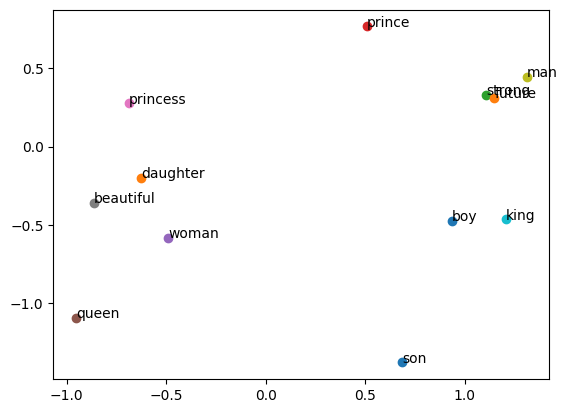

In [18]:
import matplotlib.pyplot as plt

for word in all_words:
  cords = word_embeddings[word]
  plt.scatter(cords[0], cords[1])
  plt.annotate(word, (cords[0], cords[1]))

plt.show()